# 1. Import dan Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import warnings
import sys, os

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

sys.path.append('../src')
from io_utils import load_parquet, load_json, save_json, save_object, DATA_PROCESSED

df = load_parquet('loan_cleaned_v2.parquet')
inverse_mapping = {int(k): v for k, v in load_json('inverse_mapping_v2.json').items()}

print(f'Shape data bersih: {df.shape}')
df.head(3)

Shape data bersih: (887379, 29)


,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,purpose,dti,delinq_2yrs,inq_last_6mths,mths_since_last_delinq,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,collections_12_mths_ex_med,application_type,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim,credit_history_months,target
0,5000.0,36.0,10.65,162.87,B,B2,10.0,RENT,24000.0,Verified,credit_card,27.65,0.0,1.0,NaN,3.0,0.0,13648.0,83.7,9.0,f,0.0,INDIVIDUAL,0.0,NaN,NaN,NaN,322.9,1
1,2500.0,60.0,15.27,59.83,C,C4,0.5,RENT,30000.0,Source Verified,car,1.00,0.0,5.0,NaN,3.0,0.0,1687.0,9.4,4.0,f,0.0,INDIVIDUAL,0.0,NaN,NaN,NaN,152.0,2
2,2400.0,36.0,15.96,84.33,C,C5,10.0,RENT,12252.0,Not Verified,small_business,8.72,0.0,2.0,NaN,2.0,0.0,2956.0,98.5,10.0,f,0.0,INDIVIDUAL,0.0,NaN,NaN,NaN,121.0,1


# 2.Remap Target

In [2]:
# Prime=0, Performing=1, Non-Performing=2
# Catatan: "Under-performing" (In Grace Period, Late 16-30 hari) DIGABUNG
# ke Non-Performing, bukan dipisah jadi kelas ke-4.
status_to_risk = {
    'Fully Paid':                                          0,
    'Does not meet the credit policy. Status:Fully Paid':  0,
    'Current':                                             1,
    'Issued':                                              1,
    'In Grace Period':                                     2,
    'Late (16-30 days)':                                   2,
    'Late (31-120 days)':                                  2,
    'Charged Off':                                         2,
    'Default':                                             2,
    'Does not meet the credit policy. Status:Charged Off': 2,
}

int_to_risk = {
    int_val: status_to_risk[nama]
    for int_val, nama in inverse_mapping.items()
    if nama in status_to_risk
}

df['risk_class'] = df['target'].map(int_to_risk)
df = df.drop(columns=['target']).dropna(subset=['risk_class'])
df['risk_class'] = df['risk_class'].astype(int)

label_names = {0: 'Prime', 1: 'Performing', 2: 'Non-Performing'}
print("Distribusi kelas:")
for k, v in df['risk_class'].value_counts().sort_index().items():
    print(f"  {k} ({label_names[k]}): {v:,} ({v/len(df)*100:.1f}%)")

Distribusi kelas:
  0 (Prime): 209,711 (23.6%)
  1 (Performing): 610,239 (68.8%)
  2 (Non-Performing): 67,429 (7.6%)


# 3.Encoding Kategorikal

In [3]:
# --- Ordinal: sub_grade (A1=0 ... G5=34) ---
sub_grade_order = [f"{g}{n}" for g in "ABCDEFG" for n in range(1, 6)]
sub_grade_map = {sg: i for i, sg in enumerate(sub_grade_order)}
df['sub_grade_enc'] = df['sub_grade'].map(sub_grade_map)

# --- Ordinal: verification_status (LabelEncoder manual, bukan OHE) ---
verif_map = {'Not Verified': 0, 'Source Verified': 1, 'Verified': 2}
df['verification_status_enc'] = df['verification_status'].map(verif_map)

# Drop kolom mentah yang sudah tergantikan
df = df.drop(columns=['grade', 'sub_grade', 'initial_list_status', 'verification_status'])

# --- One-hot: purpose, semua kategori KECUALI 'other' ---
purpose_dummies = pd.get_dummies(df['purpose'], prefix='purpose')
purpose_dummies = purpose_dummies.drop(columns=['purpose_other'], errors='ignore')
df = pd.concat([df.drop(columns=['purpose']), purpose_dummies], axis=1)

# --- One-hot: home_ownership, SEMUA kategori dipertahankan ---
home_dummies = pd.get_dummies(df['home_ownership'], prefix='home_ownership')
df = pd.concat([df.drop(columns=['home_ownership']), home_dummies], axis=1)

# --- One-hot: application_type (cuma 2 kategori, drop_first cukup) ---
df = pd.get_dummies(df, columns=['application_type'], prefix='application_type', drop_first=True)

onehot_like_cols = [c for c in df.columns if c.startswith(('purpose_', 'home_ownership_', 'application_type_'))]
df[onehot_like_cols] = df[onehot_like_cols].astype(int)

remaining_obj = df.select_dtypes(include='object').columns.tolist()
assert not remaining_obj, f"Masih ada kolom string yang belum di-encode: {remaining_obj}"

print(f"Shape setelah encoding: {df.shape}")

Shape setelah encoding: (887379, 44)


# 4.Split Train/Val/Test

In [4]:
from sklearn.model_selection import train_test_split

feature_cols = [c for c in df.columns if c != 'risk_class']
X_all = df[feature_cols].copy()
y_all = df['risk_class'].copy()

X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_all, test_size=0.30, stratify=y_all, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print(f"Train : {X_train.shape[0]:,} ({len(X_train)/len(X_all)*100:.0f}%)")
print(f"Val   : {X_val.shape[0]:,} ({len(X_val)/len(X_all)*100:.0f}%)")
print(f"Test  : {X_test.shape[0]:,} ({len(X_test)/len(X_all)*100:.0f}%)")

Train : 621,165 (70%)
Val   : 133,107 (15%)
Test  : 133,107 (15%)


# 5.Imputasi Missing Values

In [5]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=feature_cols, index=X_train.index)
X_val_imp   = pd.DataFrame(imputer.transform(X_val),   columns=feature_cols, index=X_val.index)
X_test_imp  = pd.DataFrame(imputer.transform(X_test),  columns=feature_cols, index=X_test.index)

print(f"Missing value tersisa (train/val/test): "
      f"{X_train_imp.isnull().sum().sum()}/{X_val_imp.isnull().sum().sum()}/{X_test_imp.isnull().sum().sum()}")

Missing value tersisa (train/val/test): 0/0/0


# 6. Seleksi Fitur

Kolom near-constant dibuang: ['home_ownership_ANY', 'home_ownership_NONE']
Random Forest explorer selesai dilatih.
RANKING SELURUH FITUR


,Feature,Importance_Mean,Importance_STD
0,tot_cur_bal,0.06392,0.00088
1,int_rate,0.05152,0.00039
2,total_rev_hi_lim,0.02604,0.00018
3,sub_grade_enc,0.02527,0.00086
4,term,0.01152,0.00025
5,dti,0.00565,0.00041
6,loan_amnt,0.00517,0.00039
7,verification_status_enc,0.00448,0.00036
8,installment,0.00336,0.00018
9,inq_last_6mths,0.00286,0.00048



15 FITUR TERBAIK


,Feature,Importance_Mean,Importance_STD
0,tot_cur_bal,0.06392,0.00088
1,int_rate,0.05152,0.00039
2,total_rev_hi_lim,0.02604,0.00018
3,sub_grade_enc,0.02527,0.00086
4,term,0.01152,0.00025
5,dti,0.00565,0.00041
6,loan_amnt,0.00517,0.00039
7,verification_status_enc,0.00448,0.00036
8,installment,0.00336,0.00018
9,inq_last_6mths,0.00286,0.00048



15 FITUR TERBURUK


,Feature,Importance_Mean,Importance_STD
26,purpose_major_purchase,0.00008,0.00006
27,purpose_car,0.00007,0.00006
28,collections_12_mths_ex_med,0.00007,0.00003
29,purpose_house,0.00005,0.00003
30,home_ownership_OWN,0.00004,0.00013
31,purpose_medical,0.00004,0.00003
32,acc_now_delinq,0.00001,0.00002
33,purpose_home_improvement,0.00000,0.00006
34,application_type_JOINT,0.00000,0.00000
35,purpose_educational,0.00000,0.00000


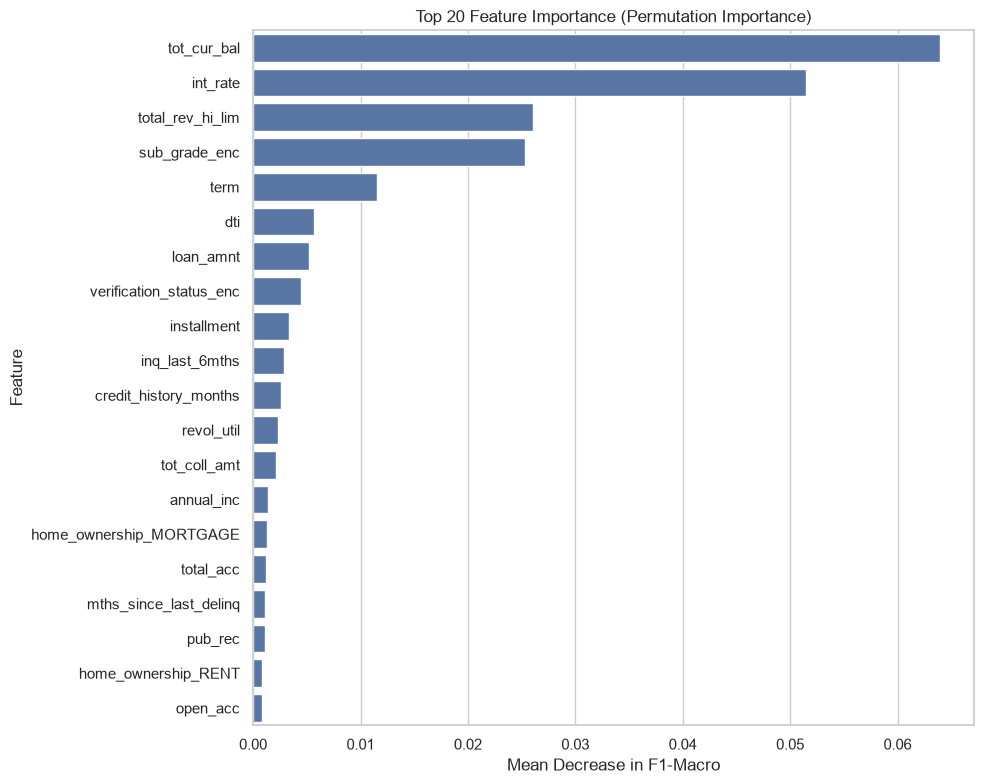


Jumlah fitur awal : 43
Jumlah fitur terpilih : 34

Fitur terpilih:
['tot_cur_bal', 'int_rate', 'total_rev_hi_lim', 'sub_grade_enc', 'term', 'dti', 'loan_amnt', 'verification_status_enc', 'installment', 'inq_last_6mths', 'credit_history_months', 'revol_util', 'tot_coll_amt', 'annual_inc', 'home_ownership_MORTGAGE', 'total_acc', 'mths_since_last_delinq', 'pub_rec', 'home_ownership_RENT', 'open_acc', 'purpose_debt_consolidation', 'emp_length', 'purpose_credit_card', 'delinq_2yrs', 'purpose_small_business', 'purpose_wedding', 'purpose_major_purchase', 'purpose_car', 'collections_12_mths_ex_med', 'purpose_house', 'home_ownership_OWN', 'purpose_medical', 'acc_now_delinq', 'purpose_home_improvement']


In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer, f1_score

# =====================================================
# Hapus fitur near-constant
# =====================================================

variances = X_train_imp.var()

near_constant = variances[variances < 1e-4].index.tolist()

if near_constant:
    print(f"Kolom near-constant dibuang: {near_constant}")

candidate_cols = [c for c in feature_cols if c not in near_constant]

# =====================================================
# Train Random Forest sebagai Explorer Model
# =====================================================

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(
    X_train_imp[candidate_cols],
    y_train
)

print("Random Forest explorer selesai dilatih.")

# =====================================================
# Permutation Importance
# =====================================================

scorer = make_scorer(
    f1_score,
    average="macro",
    zero_division=0
)

perm_result = permutation_importance(
    estimator=rf,
    X=X_val_imp[candidate_cols],
    y=y_val,
    scoring=scorer,
    n_repeats=5,
    random_state=42,
    n_jobs=1
)

feature_scores = pd.DataFrame({
    "Feature": candidate_cols,
    "Importance_Mean": perm_result.importances_mean,
    "Importance_STD": perm_result.importances_std
})

feature_scores = feature_scores.sort_values(
    by="Importance_Mean",
    ascending=False
).reset_index(drop=True)

# =====================================================
# Ranking seluruh fitur
# =====================================================

print("="*70)
print("RANKING SELURUH FITUR")
print("="*70)

display(feature_scores.round(5))

# =====================================================
# 15 fitur terbaik
# =====================================================

print("\n15 FITUR TERBAIK")

display(feature_scores.head(15).round(5))

# =====================================================
# 15 fitur terburuk
# =====================================================

print("\n15 FITUR TERBURUK")

display(feature_scores.tail(15).round(5))

# =====================================================
# Visualisasi 20 fitur terbaik
# =====================================================

plt.figure(figsize=(10,8))

sns.barplot(
    data=feature_scores.head(20),
    x="Importance_Mean",
    y="Feature",
)

plt.title("Top 20 Feature Importance (Permutation Importance)")
plt.xlabel("Mean Decrease in F1-Macro")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

# =====================================================
# Pilih fitur
# =====================================================

# Semua fitur yang memberikan kontribusi positif
selected_features = feature_scores.loc[
    feature_scores["Importance_Mean"] > 0,
    "Feature"
].tolist()

print("\nJumlah fitur awal :", len(feature_cols))
print("Jumlah fitur terpilih :", len(selected_features))

print("\nFitur terpilih:")
print(selected_features)

# 7.Fitur terpilih

In [7]:
X_train_sel = X_train_imp[selected_features].copy()
X_val_sel   = X_val_imp[selected_features].copy()
X_test_sel  = X_test_imp[selected_features].copy()

print(f"Jumlah fitur terpilih: {len(selected_features)}")
print(selected_features)

Jumlah fitur terpilih: 34
['tot_cur_bal', 'int_rate', 'total_rev_hi_lim', 'sub_grade_enc', 'term', 'dti', 'loan_amnt', 'verification_status_enc', 'installment', 'inq_last_6mths', 'credit_history_months', 'revol_util', 'tot_coll_amt', 'annual_inc', 'home_ownership_MORTGAGE', 'total_acc', 'mths_since_last_delinq', 'pub_rec', 'home_ownership_RENT', 'open_acc', 'purpose_debt_consolidation', 'emp_length', 'purpose_credit_card', 'delinq_2yrs', 'purpose_small_business', 'purpose_wedding', 'purpose_major_purchase', 'purpose_car', 'collections_12_mths_ex_med', 'purpose_house', 'home_ownership_OWN', 'purpose_medical', 'acc_now_delinq', 'purpose_home_improvement']


# 8. Normalisasi (StandarScaler)

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_sel), columns=selected_features, index=X_train_sel.index)
X_val_scaled   = pd.DataFrame(scaler.transform(X_val_sel),   columns=selected_features, index=X_val_sel.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test_sel),  columns=selected_features, index=X_test_sel.index)

print(f"Mean train setelah scaling (~0):\n{X_train_scaled.mean().round(4)}")
print(f"\nStd train setelah scaling (~1):\n{X_train_scaled.std().round(4)}")

Mean train setelah scaling (~0):
tot_cur_bal                   0.0
int_rate                     -0.0
total_rev_hi_lim              0.0
sub_grade_enc                -0.0
term                          0.0
dti                          -0.0
loan_amnt                     0.0
verification_status_enc      -0.0
installment                   0.0
inq_last_6mths               -0.0
credit_history_months         0.0
revol_util                   -0.0
tot_coll_amt                 -0.0
annual_inc                   -0.0
home_ownership_MORTGAGE      -0.0
total_acc                     0.0
mths_since_last_delinq       -0.0
pub_rec                       0.0
home_ownership_RENT          -0.0
open_acc                     -0.0
purpose_debt_consolidation    0.0
emp_length                   -0.0
purpose_credit_card          -0.0
delinq_2yrs                   0.0
purpose_small_business        0.0
purpose_wedding              -0.0
purpose_major_purchase        0.0
purpose_car                   0.0
collections_12_

In [10]:
# ================================================
# 9. SMOTE — hanya untuk data train, disimpan TERPISAH
#    dari train asli (supaya bisa dibandingkan apple-to-apple
#    di 04b: E1-E6 pakai train asli, E7 pakai train_v2_smote)
# ================================================
from imblearn.over_sampling import SMOTE

print("Distribusi sebelum SMOTE:")
print(y_train.value_counts().sort_index())

n_majority = y_train.value_counts().max()
sampling_strategy = {2: int(n_majority * 0.4)}  # Non-Performing -> ~40% dari Performing

smote = SMOTE(sampling_strategy=sampling_strategy, k_neighbors=5, random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("\nDistribusi setelah SMOTE:")
print(pd.Series(y_train_smote).value_counts().sort_index())

Distribusi sebelum SMOTE:
risk_class
0    146798
1    427167
2     47200
Name: count, dtype: int64

Distribusi setelah SMOTE:
risk_class
0    146798
1    427167
2    170866
Name: count, dtype: int64


# 9. Class Weight

In [11]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = {int(c): float(w) for c, w in zip(classes, weights)}

print("Class weight (dari train set):")
for k, v in class_weight_dict.items():
    print(f"  {label_names[k]}: {v:.3f}")

Class weight (dari train set):
  Prime: 1.410
  Performing: 0.485
  Non-Performing: 4.387


In [12]:
save_object(imputer, 'imputer_v2.pkl')
save_object(scaler, 'scaler_v2.pkl')

save_json(selected_features, 'selected_features_v2.json')
save_json(label_names, 'label_names_v2.json')
save_json(class_weight_dict, 'class_weight_v2.json')
save_json(sub_grade_map, 'sub_grade_mapping_v2.json')

# --- Train asli (untuk E1-E6) ---
train_df = X_train_scaled.copy()
train_df['risk_class'] = y_train.values
train_df.to_parquet(os.path.join(DATA_PROCESSED, 'train_v2.parquet'), index=False)

# --- Train hasil SMOTE (untuk E7 SAJA) ---
train_smote_df = pd.DataFrame(X_train_smote, columns=selected_features)
train_smote_df['risk_class'] = y_train_smote.values if hasattr(y_train_smote, 'values') else y_train_smote
train_smote_df.to_parquet(os.path.join(DATA_PROCESSED, 'train_v2_smote.parquet'), index=False)

# --- Val & Test (TIDAK di-SMOTE, biar evaluasi tetap realistis) ---
val_df  = X_val_scaled.copy();  val_df['risk_class']  = y_val.values
test_df = X_test_scaled.copy(); test_df['risk_class'] = y_test.values
val_df.to_parquet(os.path.join(DATA_PROCESSED, 'val_v2.parquet'), index=False)
test_df.to_parquet(os.path.join(DATA_PROCESSED, 'test_v2.parquet'), index=False)

print('Artifact v2 tersimpan: imputer_v2.pkl, scaler_v2.pkl, selected_features_v2.json, '
      'label_names_v2.json, class_weight_v2.json, sub_grade_mapping_v2.json')
print(f'train_v2: {train_df.shape} | train_v2_smote: {train_smote_df.shape} | '
      f'val_v2: {val_df.shape} | test_v2: {test_df.shape}')

Artifact v2 tersimpan: imputer_v2.pkl, scaler_v2.pkl, selected_features_v2.json, label_names_v2.json, class_weight_v2.json, sub_grade_mapping_v2.json
train_v2: (621165, 35) | train_v2_smote: (744831, 35) | val_v2: (133107, 35) | test_v2: (133107, 35)
